# Analysing Sentiment, Emotion, and Polarisation in Reddit Discussions on the Palestine-Israel Conflict Using Machine Learning

## Member 1: Data & Traditional ML Lead

This member focuses on dataset preparation, text preprocessing, TF-IDF feature extraction, traditional machine learning model training, and model evaluation.


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/galohsafiya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/galohsafiya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/galohsafiya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/galohsafiya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/galohsafiya/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/galohsafiya/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## 2. Load Dataset

In [4]:
df = pd.read_csv("reddit_dataset.csv")

df.head()

,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time,combined_text,clean_text,processed_text,compound,sentiment
0,onkan89,1,That's just Palestine's history lol,IsraelPalestine,2026-05-24 07:15:09,1tlvu9b,Late_Ad2203,0,1,0,...,Gaza floatila activists beaten up and detained...,0.85,78,0,2026-05-23 23:42:20,Gaza floatila activists beaten up and detained...,gaza floatila activists beaten up and detained...,gaza floatila activist beaten detained spanish...,0.1280,positive
1,onkalu2,1,Just going to leave this here. Israel are defe...,IsraelPalestine,2026-05-24 07:14:48,1tlvu9b,Late_Ad2203,0,1,0,...,Gaza floatila activists beaten up and detained...,0.85,78,0,2026-05-23 23:42:20,Gaza floatila activists beaten up and detained...,gaza floatila activists beaten up and detained...,gaza floatila activist beaten detained spanish...,-0.5574,negative
2,onkakbn,1,What kind of physical evidence would it leave ...,IsraelPalestine,2026-05-24 07:14:26,1tkmfii,OneReportersOpinion,0,1,0,...,More thoughts on the Kristof opinion editorial,0.74,18,0,2026-05-22 15:31:32,More thoughts on the Kristof opinion editorial...,more thoughts on the kristof opinion editorial...,thought kristof opinion editorial kind physica...,0.4812,positive
3,onka939,1,I mean... you mention that this documentation ...,IsraelPalestine,2026-05-24 07:11:45,1tlx2k8,warsage,0,1,0,...,An investigation into sexual assault in the Is...,0.50,0,0,2026-05-24 00:37:21,An investigation into sexual assault in the Is...,an investigation into sexual assault in the is...,investigation sexual assault israelpalestine c...,-0.9964,negative
4,onka51q,1,An airport is not the best place to cause trou...,worldnews,2026-05-24 07:10:46,1tllkrd,Efficient-Wolf7068,0,1,0,...,Clashes in Spain: Gaza flotilla activists beat...,0.87,2540,0,2026-05-23 16:47:24,Clashes in Spain: Gaza flotilla activists beat...,clashes in spain gaza flotilla activists beate...,clash spain gaza flotilla activist beaten poli...,-0.0772,negative


## 3. Dataset Overview

In [5]:
df.shape

(353472, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353472 entries, 0 to 353471
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   comment_id                  353472 non-null  object 
 1   score                       353472 non-null  int64  
 2   self_text                   353471 non-null  object 
 3   subreddit                   353472 non-null  object 
 4   created_time                353472 non-null  object 
 5   post_id                     353472 non-null  object 
 6   author_name                 353472 non-null  object 
 7   controversiality            353472 non-null  int64  
 8   ups                         353472 non-null  int64  
 9   downs                       353472 non-null  int64  
 10  user_is_verified            353472 non-null  bool   
 11  user_account_created_time   348137 non-null  object 
 12  user_awardee_karma          353420 non-null  float64
 13  user_awarder_k

In [7]:
df.columns

Index(['comment_id', 'score', 'self_text', 'subreddit', 'created_time',
       'post_id', 'author_name', 'controversiality', 'ups', 'downs',
       'user_is_verified', 'user_account_created_time', 'user_awardee_karma',
       'user_awarder_karma', 'user_link_karma', 'user_comment_karma',
       'user_total_karma', 'post_score', 'post_self_text', 'post_title',
       'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received',
       'post_created_time', 'combined_text', 'clean_text', 'processed_text',
       'compound', 'sentiment'],
      dtype='object')

In [8]:
df.isnull().sum()

comment_id                         0
score                              0
self_text                          1
subreddit                          0
created_time                       0
post_id                            0
author_name                        0
controversiality                   0
ups                                0
downs                              0
user_is_verified                   0
user_account_created_time       5335
user_awardee_karma                52
user_awarder_karma                52
user_link_karma                   52
user_comment_karma                52
user_total_karma                  52
post_score                         0
post_self_text                191968
post_title                         0
post_upvote_ratio                  0
post_thumbs_ups                    0
post_total_awards_received         0
post_created_time                  0
combined_text                      0
clean_text                         0
processed_text                     5
c

In [9]:
df.duplicated().sum()

np.int64(0)

## 4. Exploratory Data Analysis (EDA)

#### EDA 1: Dataset Size

In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 353472
Number of columns: 29


#### EDA 2: Missing Values

In [11]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

post_self_text               191968
user_account_created_time      5335
user_link_karma                  52
user_comment_karma               52
user_awarder_karma               52
user_awardee_karma               52
user_total_karma                 52
processed_text                    5
self_text                         1
dtype: int64

#### EDA 3: Duplicate Rows

In [12]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


#### EDA 4: Subreddit Distribution

In [13]:
df["subreddit"].value_counts().head(10)

subreddit
IsraelPalestine       106507
worldnews             103112
PublicFreakout         55410
Palestine              33190
CombatFootage          21228
AskMiddleEast          12692
NonCredibleDefense      7466
CrazyFuckingVideos      5872
worldnewsvideo          4637
NoahGetTheBoat          1535
Name: count, dtype: int64

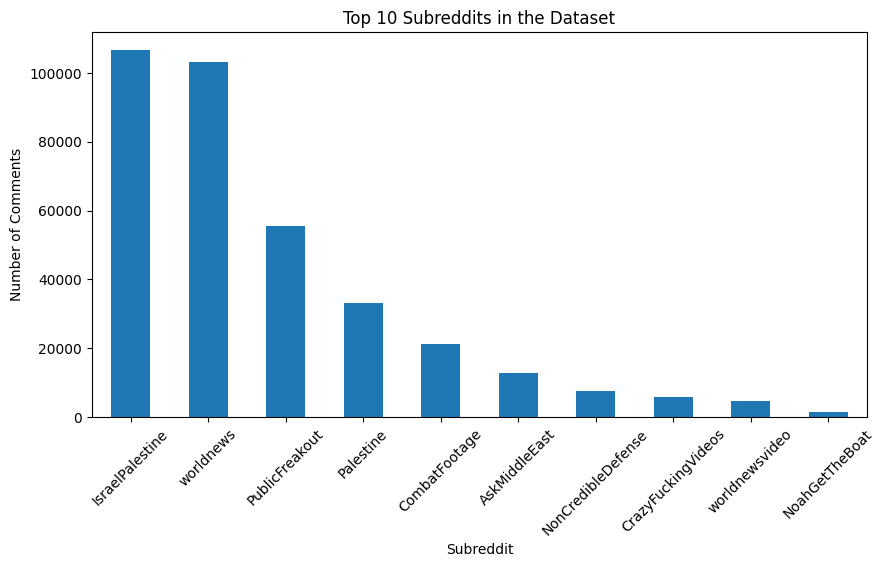

In [14]:
plt.figure(figsize=(10,5))
df["subreddit"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Subreddits in the Dataset")
plt.xlabel("Subreddit")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

#### EDA 5: Text Length Analysis

In [15]:
df["text_length"] = df["self_text"].fillna("").astype(str).apply(len)
df["word_count"] = df["self_text"].fillna("").astype(str).apply(lambda x: len(x.split()))

In [16]:
df[["text_length", "word_count"]].describe()

,text_length,word_count
count,353472.000000,353472.000000
mean,234.428014,39.098675
std,391.569613,62.817871
min,0.000000,0.000000
25%,54.000000,9.000000
50%,115.000000,20.000000
75%,254.000000,43.000000
max,9929.000000,1653.000000


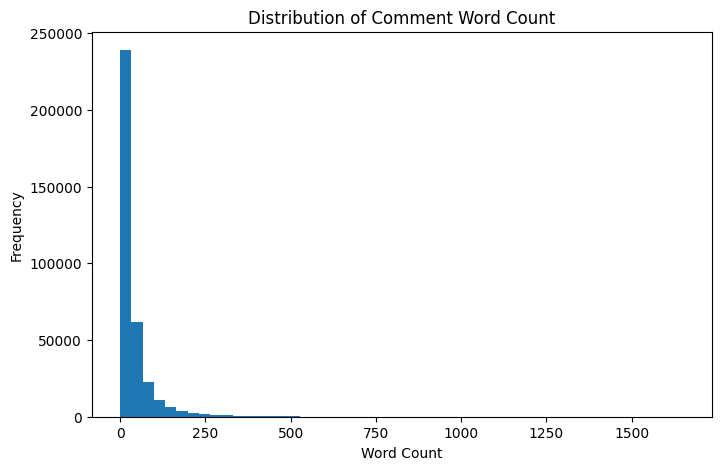

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Comment Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#### EDA 6: Engagement Features

In [18]:
df[["score", "ups", "downs", "controversiality"]].describe()

,score,ups,downs,controversiality
count,353472.000000,353472.000000,353472.0,353472.000000
mean,29.743468,29.743468,0.0,0.076167
std,248.091525,248.091525,0.0,0.265266
min,-549.000000,-549.000000,0.0,0.000000
25%,1.000000,1.000000,0.0,0.000000
50%,3.000000,3.000000,0.0,0.000000
75%,11.000000,11.000000,0.0,0.000000
max,31613.000000,31613.000000,0.0,1.000000


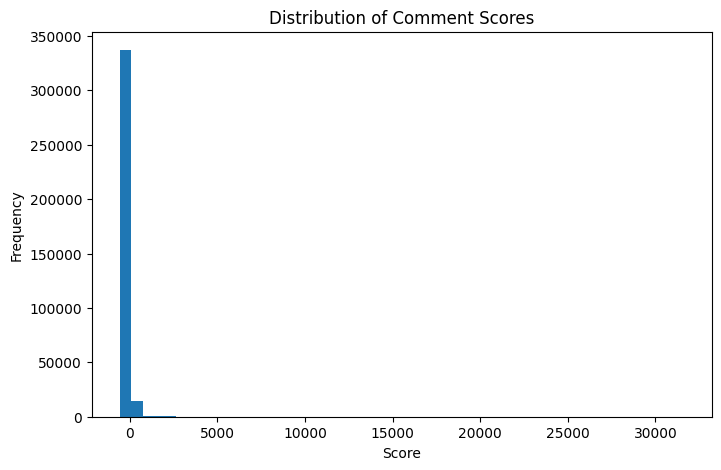

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["score"], bins=50)
plt.title("Distribution of Comment Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [20]:
df["controversiality"].value_counts()

controversiality
0    326549
1     26923
Name: count, dtype: int64

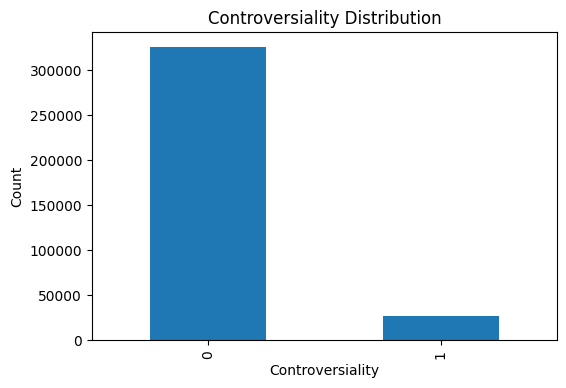

In [21]:
plt.figure(figsize=(6,4))
df["controversiality"].value_counts().plot(kind="bar")
plt.title("Controversiality Distribution")
plt.xlabel("Controversiality")
plt.ylabel("Count")
plt.show()

#### EDA 7: Time-based Analysis

In [22]:
df["created_time"] = pd.to_datetime(df["created_time"], errors="coerce")
df["date"] = df["created_time"].dt.date

In [23]:
comments_by_date = df.groupby("date").size()

comments_by_date.head()

date
2026-01-01    1250
2026-01-02    1503
2026-01-03    1574
2026-01-04    1814
2026-01-05    1934
dtype: int64

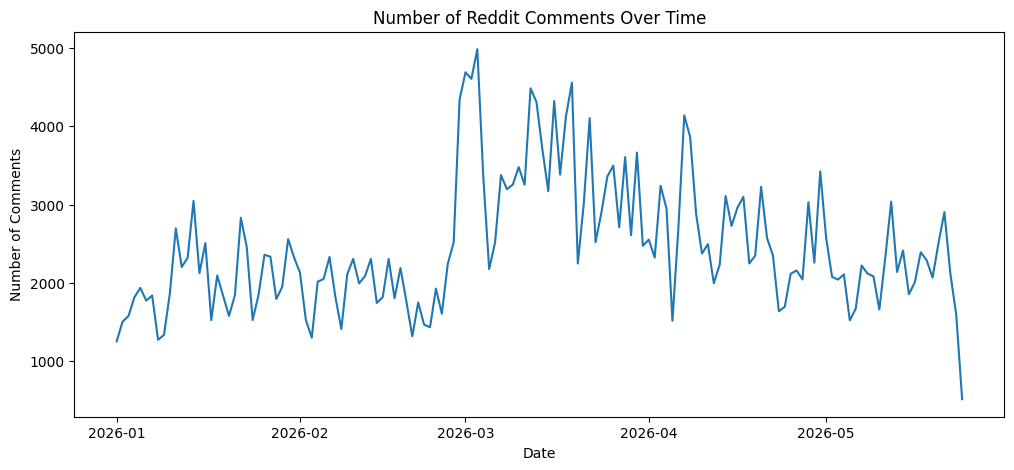

In [24]:
plt.figure(figsize=(12,5))
comments_by_date.plot()
plt.title("Number of Reddit Comments Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Comments")
plt.show()

## 5. Select Text Column

In [25]:
df.columns

Index(['comment_id', 'score', 'self_text', 'subreddit', 'created_time',
       'post_id', 'author_name', 'controversiality', 'ups', 'downs',
       'user_is_verified', 'user_account_created_time', 'user_awardee_karma',
       'user_awarder_karma', 'user_link_karma', 'user_comment_karma',
       'user_total_karma', 'post_score', 'post_self_text', 'post_title',
       'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received',
       'post_created_time', 'combined_text', 'clean_text', 'processed_text',
       'compound', 'sentiment', 'text_length', 'word_count', 'date'],
      dtype='object')

In [26]:
df["combined_text"] = (
    df["post_title"].fillna("") + " " +
    df["self_text"].fillna("")
)

text_column = "combined_text"

df[[text_column]].head()

,combined_text
0,Gaza floatila activists beaten up and detained...
1,Gaza floatila activists beaten up and detained...
2,More thoughts on the Kristof opinion editorial...
3,An investigation into sexual assault in the Is...
4,Clashes in Spain: Gaza flotilla activists beat...


In [27]:
df[text_column].isnull().sum()

np.int64(0)

In [28]:
df[text_column].head(10)

0    Gaza floatila activists beaten up and detained...
1    Gaza floatila activists beaten up and detained...
2    More thoughts on the Kristof opinion editorial...
3    An investigation into sexual assault in the Is...
4    Clashes in Spain: Gaza flotilla activists beat...
5    TRT World - France bans Israel's Ben-Gvir over...
6    Israel intercepts the Gaza flotilla and deport...
7    I'm the only Pro-Israel student in my universi...
8    Israel intercepts the Gaza flotilla and deport...
9    I'm the only Pro-Israel student in my universi...
Name: combined_text, dtype: object

## 6. Remove Missing and Duplicate Text

In [29]:
df = df[df[text_column].astype(str).str.strip() != ""]

In [30]:
df = df.drop_duplicates(subset=[text_column])

In [31]:
df.shape

(353472, 32)

## 7. Data Cleaning

In [32]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [33]:
df["clean_text"] = df[text_column].apply(clean_text)

df[[text_column, "clean_text"]].head()

,combined_text,clean_text
0,Gaza floatila activists beaten up and detained...,gaza floatila activists beaten up and detained...
1,Gaza floatila activists beaten up and detained...,gaza floatila activists beaten up and detained...
2,More thoughts on the Kristof opinion editorial...,more thoughts on the kristof opinion editorial...
3,An investigation into sexual assault in the Is...,an investigation into sexual assault in the is...
4,Clashes in Spain: Gaza flotilla activists beat...,clashes in spain gaza flotilla activists beate...


## 8. Text Preprocessing

In [34]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [35]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [36]:
df["processed_text"] = df["clean_text"].apply(preprocess_text)

df[["clean_text", "processed_text"]].head()

,clean_text,processed_text
0,gaza floatila activists beaten up and detained...,gaza floatila activist beaten detained spanish...
1,gaza floatila activists beaten up and detained...,gaza floatila activist beaten detained spanish...
2,more thoughts on the kristof opinion editorial...,thought kristof opinion editorial kind physica...
3,an investigation into sexual assault in the is...,investigation sexual assault israelpalestine c...
4,clashes in spain gaza flotilla activists beate...,clash spain gaza flotilla activist beaten poli...


## 9. Sentiment Label Preparation

In [37]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [38]:
df["compound"] = df["processed_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [39]:
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [40]:
df["sentiment"] = df["compound"].apply(label_sentiment)

target_column = "sentiment"

df["sentiment"].value_counts()

sentiment
negative    212125
positive    113230
neutral      28117
Name: count, dtype: int64

## 10. Check Class Distribution

In [41]:
df[target_column].value_counts()

sentiment
negative    212125
positive    113230
neutral      28117
Name: count, dtype: int64

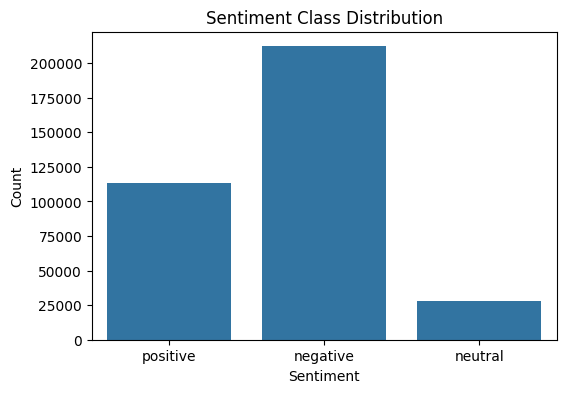

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_column)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## 11. Train-Test Split

In [43]:
X_text = df["processed_text"]
y = df[target_column]

In [44]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print("Training size:", X_train_text.shape)
print("Testing size:", X_test_text.shape)

Training size: (282777,)
Testing size: (70695,)


## 12. TF-IDF Feature Extraction

In [46]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [47]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [48]:
print("TF-IDF training shape:", X_train.shape)
print("TF-IDF testing shape:", X_test.shape)

TF-IDF training shape: (282777, 5000)
TF-IDF testing shape: (70695, 5000)


## 13. SMOTE (Class Imbalance Handling)
As of now, the dataset has an imbalanced number between the sentiments; negative, positive, and neutral. Therefore, we will apply SMOTE to handle the class imbalance between the sentiments to ensure better model training.

In [49]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [93]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({'negative': 169700, 'positive': 90584, 'neutral': 22493})
After SMOTE: Counter({'negative': 169700, 'positive': 169700, 'neutral': 169700})


## 14. Logistic Regression Model

Logistic Regression is trained as one of the traditional machine learning models for sentiment classification.

In [94]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_smote, y_train_smote)

lr_pred = lr_model.predict(X_test)

In [95]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8311620340901054
              precision    recall  f1-score   support

    negative       0.93      0.84      0.88     42425
     neutral       0.48      0.76      0.59      5624
    positive       0.80      0.83      0.81     22646

    accuracy                           0.83     70695
   macro avg       0.74      0.81      0.76     70695
weighted avg       0.85      0.83      0.84     70695



## 15. Naive Bayes Model

Naive Bayes is trained as a baseline model because it is commonly used for text classification tasks.

In [96]:
nb_model = MultinomialNB()
nb_model.fit(X_train_smote, y_train_smote)

nb_pred = nb_model.predict(X_test)

In [97]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7089751750477403
              precision    recall  f1-score   support

    negative       0.87      0.73      0.79     42425
     neutral       0.33      0.65      0.44      5624
    positive       0.65      0.68      0.67     22646

    accuracy                           0.71     70695
   macro avg       0.62      0.69      0.63     70695
weighted avg       0.75      0.71      0.72     70695



## 16. Support Vector Machine with Hyperparameter Tuning (GridSearchCV)

While LinearSVC works exceptionally well with high-dimensional TF-IDF text features, its performance depends heavily on finding the right regularization parameter (C). To optimize the model, we implement GridSearchCV (Grid Search Cross-Validation)

In [98]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

# Define the grid parameters to test
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    LinearSVC(max_iter=2000), # Increased max_iter slightly to ensure convergence
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

svm_model = grid_search.best_estimator_

svm_pred = svm_model.predict(X_test)

Best Parameters: {'C': 10}
Best Score: 0.8574445099194656


In [99]:
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.838234670061532
              precision    recall  f1-score   support

    negative       0.93      0.85      0.89     42425
     neutral       0.50      0.77      0.60      5624
    positive       0.81      0.83      0.82     22646

    accuracy                           0.84     70695
   macro avg       0.75      0.82      0.77     70695
weighted avg       0.86      0.84      0.84     70695



## 17. K-Fold Cross Validation

In [57]:
from sklearn.model_selection import cross_val_score

svm_model = grid_search.best_estimator_ 

cv_scores = cross_val_score(
    svm_model,
    X_train_smote,  
    y_train_smote,  
    cv=5,
    scoring='accuracy',
    n_jobs=-1     
)

print("Cross Validation Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100:.2f}%")

Cross Validation Scores: [0.83409939 0.85925162 0.86061677 0.86664702 0.86660774]
Mean Accuracy: 85.74%
Standard Deviation: 1.21%


## 18. Confusion Matrix

In [58]:
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred
}

labels = sorted(y.unique())

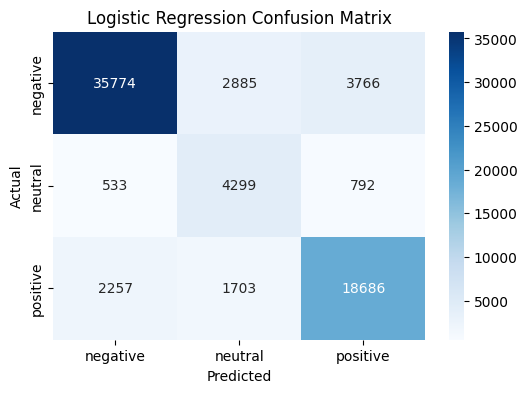

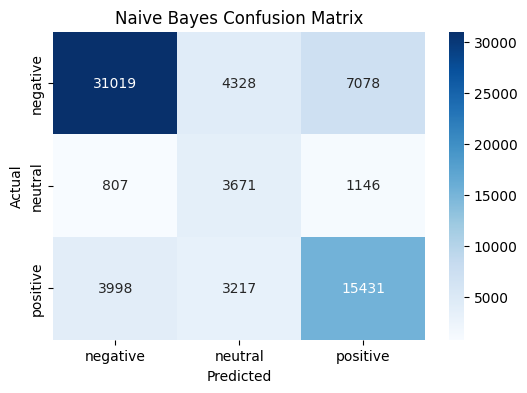

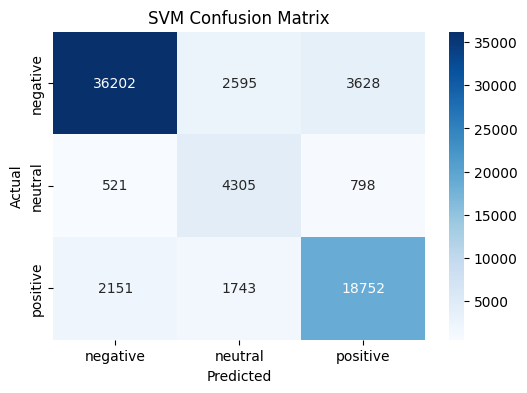

In [59]:
for name, pred in models.items():
    cm = confusion_matrix(y_test, pred, labels=labels)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 19. Model Comparison

In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    
    "Precision (Macro)": [
        precision_score(y_test, lr_pred, average="macro"),
        precision_score(y_test, nb_pred, average="macro"),
        precision_score(y_test, svm_pred, average="macro")
    ],
    
    "Recall (Macro)": [
        recall_score(y_test, lr_pred, average="macro"),
        recall_score(y_test, nb_pred, average="macro"),
        recall_score(y_test, svm_pred, average="macro")
    ],
    
    "F1-score (Macro)": [
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, nb_pred, average="macro"),
        f1_score(y_test, svm_pred, average="macro")
    ],
    
    "F1-score (Weighted)": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted")
    ]
})

results

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro),F1-score (Weighted)
0,Logistic Regression,0.831162,0.738433,0.810922,0.763442,0.838168
1,Naive Bayes,0.708975,0.615169,0.688429,0.631788,0.723989
2,SVM,0.838235,0.746133,0.815612,0.770838,0.844636


## 19.1 Overfitting Analysis

In [61]:
train_smote_acc = svm_model.score(X_train_smote, y_train_smote)

train_orig_acc = svm_model.score(X_train, y_train)

test_acc = svm_model.score(X_test, y_test)

print(f"Training Accuracy (SMOTE Balanced): {train_smote_acc * 100:.2f}%")
print(f"Training Accuracy (Original Imbalanced): {train_orig_acc * 100:.2f}%")
print(f"Testing Accuracy (Real-World Test Set): {test_acc * 100:.2f}%")

Training Accuracy (SMOTE Balanced): 86.44%
Training Accuracy (Original Imbalanced): 84.78%
Testing Accuracy (Real-World Test Set): 83.82%


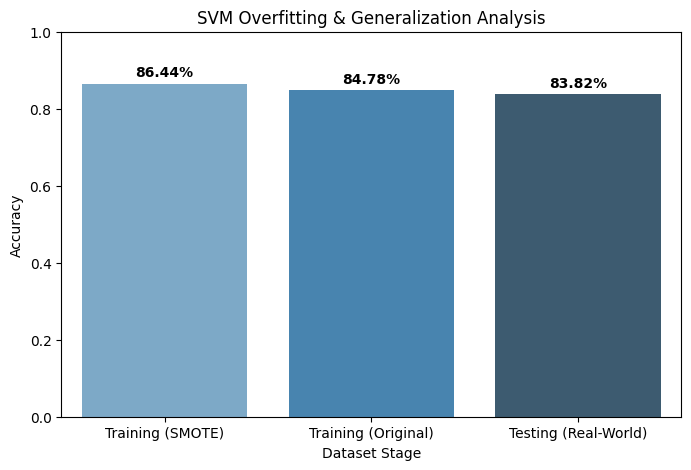

In [62]:
overfitting_data = pd.DataFrame({
    "Stage": [
        "Training (SMOTE)", 
        "Training (Original)", 
        "Testing (Real-World)"
    ],
    "Accuracy": [0.8644, 0.8478, 0.8382]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=overfitting_data, x="Stage", y="Accuracy", palette="Blues_d")

plt.title("SVM Overfitting & Generalization Analysis")
plt.ylim(0, 1)
plt.xlabel("Dataset Stage")
plt.ylabel("Accuracy")

for p in plt.gca().patches:
    plt.gca().annotate(
        f"{p.get_height()*100:.2f}%", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontweight='bold'
    )

plt.show()

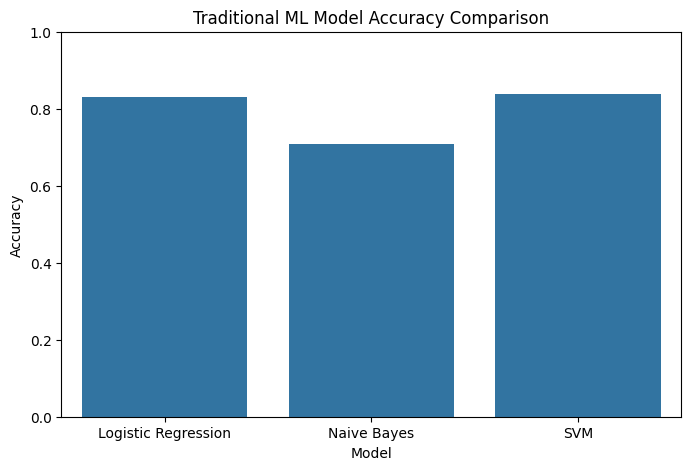

In [63]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Traditional ML Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

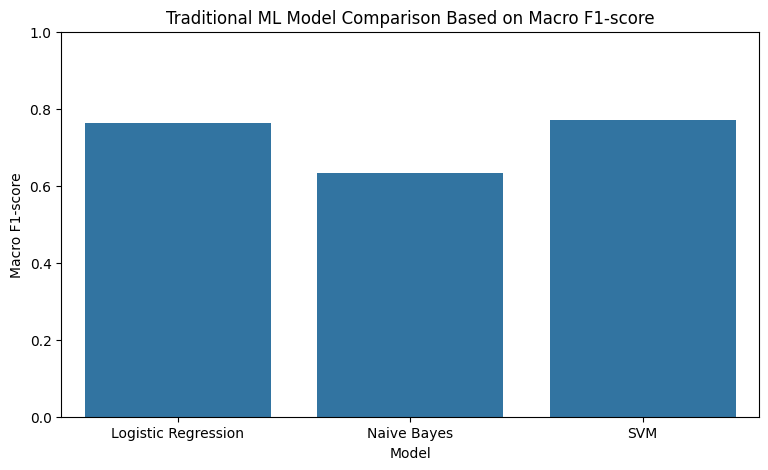

In [64]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="Model", y="F1-score (Macro)")
plt.title("Traditional ML Model Comparison Based on Macro F1-score")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.show()

## 20. Save Output

The cleaned dataset is saved for report writing, presentation, and future integration with other group members.

In [65]:
df.to_csv("cleaned_reddit_sentiment_dataset.csv", index=False)

Since the dataset did not contain predefined sentiment labels, VADER was used to generate initial sentiment classes based on compound sentiment scores. These generated labels were then used as the target variable for training traditional machine learning models.

## 21. Deep Learning & Emotion Analysis

To address the limitation from traditional machine learning model, deep learning approaches were explored. Deep learning models are capable of learning contextual and semantic relationships between words by processing text as sequences, making them particularly suitable for analyzing complex Reddit discussions related to the Palestine–Israel conflict.

### 21.1 LSTM Model

The Long Short-Term Memory (LSTM) model is implemented as the first deep learning approach for sentiment classification. LSTM is a type of Recurrent Neural Network (RNN) designed to capture long-term dependencies within textual sequences through its memory cell mechanism. Unlike traditional machine learning methods that primarily focus on word frequencies, LSTM considers the order and context of words, enabling a deeper understanding of sentiment expressed in Reddit comments.

In [69]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [49]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(
    df['sentiment']
)

In [50]:
# Save encoder
import joblib

joblib.dump(
    encoder,
    'label_encoder.pkl'
)

print("Label encoder saved.")

Label encoder saved.


In [51]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    df['clean_text'],
    df['label'],      
    test_size=0.2,
    random_state=42
)

In [52]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 150

tokenizer = Tokenizer(
    num_words=MAX_WORDS
)

tokenizer.fit_on_texts(X_train_dl)

X_train_seq = tokenizer.texts_to_sequences(X_train_dl)
X_test_seq = tokenizer.texts_to_sequences(X_test_dl)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN
)

In [53]:
joblib.dump(
    tokenizer,
    'tokenizer.pkl'
)

print("Tokenizer saved.")

Tokenizer saved.


In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

lstm_model = Sequential([

    Embedding(
        MAX_WORDS,
        128,
        input_length=MAX_LEN
    ),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')

])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [73]:
history_lstm = lstm_model.fit(
   X_train_pad,
   y_train_dl,
   epochs=5,
   batch_size=32,
   validation_split=0.2
)

Epoch 1/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 511s 72ms/step - accuracy: 0.8629 - loss: 0.3679 - val_accuracy: 0.9162 - val_loss: 0.2414
Epoch 2/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 345s 49ms/step - accuracy: 0.9307 - loss: 0.2054 - val_accuracy: 0.9325 - val_loss: 0.2026
Epoch 3/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 300s 42ms/step - accuracy: 0.9425 - loss: 0.1723 - val_accuracy: 0.9286 - val_loss: 0.2213
Epoch 4/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 298s 42ms/step - accuracy: 0.9502 - loss: 0.1478 - val_accuracy: 0.9302 - val_loss: 0.2129
Epoch 5/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 298s 42ms/step - accuracy: 0.9579 - loss: 0.1247 - val_accuracy: 0.9280 - val_loss: 0.2195


In [75]:
# Predict test set
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

lstm_pred = np.argmax(
    lstm_model.predict(X_test_pad), 
    axis=1
)

print(classification_report(
    y_test_dl, 
    lstm_pred
))

2210/2210 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     42376
           1       0.89      0.73      0.80      5690
           2       0.92      0.91      0.91     22629

    accuracy                           0.93     70695
   macro avg       0.91      0.87      0.89     70695
weighted avg       0.93      0.93      0.93     70695



In [76]:
# LSTM Metrics
lstm_accuracy = accuracy_score(
    y_test_dl,
    lstm_pred
)

lstm_precision = precision_score(
    y_test_dl,
    lstm_pred,
    average='macro'
)

lstm_recall = recall_score(
    y_test_dl,
    lstm_pred,
    average='macro'
)

lstm_f1 = f1_score(
    y_test_dl,
    lstm_pred,
    average='macro'
)

print("Accuracy:", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall:", lstm_recall)
print("F1:", lstm_f1)

Accuracy: 0.9296414173562487
Precision: 0.9148990488684171
Recall: 0.8703459157029411
F1: 0.8901700017922153


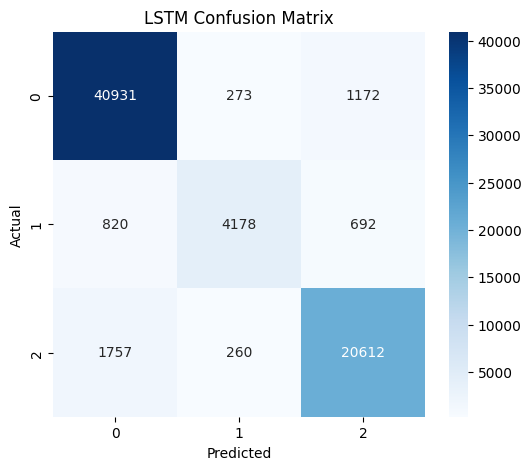

In [77]:
# LSTM Confusion Matrix
cm = confusion_matrix(
    y_test_dl,
    lstm_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

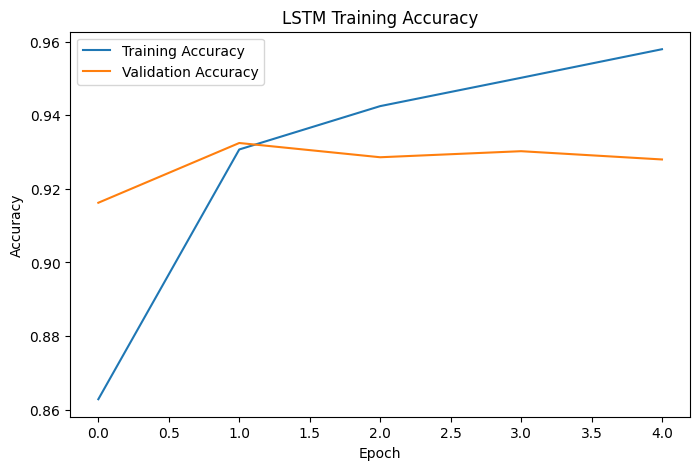

In [78]:
# LSTM Training Curve
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
lstm_model.save('lstm_model.keras')
print("LSTM model saved successfully.")

LSTM model saved successfully.


The LSTM model is saved for future use during visualizations.

### 19.2 BiLSTM Model

To further improve contextual understanding, a Bidirectional Long Short-Term Memory (BiLSTM) model was implemented. While a standard LSTM processes text from left to right, BiLSTM processes the sequence in both forward and backward directions simultaneously. This bidirectional learning allows the model to utilize information from both preceding and succeeding words, making it more effective in understanding complex sentence structures and nuanced opinions commonly found in online discussions.

In [ ]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([

    Embedding(
        MAX_WORDS,
        128,
        input_length=MAX_LEN
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')

])

In [ ]:
bilstm_model.compile(
   optimizer='adam',
   loss='sparse_categorical_crossentropy',
   metrics=['accuracy']
)

history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train_dl,
    epochs=5,
    batch_size=32,
    validation_split=0.2
) 

Epoch 1/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 942s 132ms/step - accuracy: 0.8658 - loss: 0.3614 - val_accuracy: 0.9216 - val_loss: 0.2333
Epoch 2/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 922s 130ms/step - accuracy: 0.9302 - loss: 0.2061 - val_accuracy: 0.9303 - val_loss: 0.2049
Epoch 3/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 930s 132ms/step - accuracy: 0.9413 - loss: 0.1747 - val_accuracy: 0.9328 - val_loss: 0.1987
Epoch 4/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 1142s 162ms/step - accuracy: 0.9501 - loss: 0.1491 - val_accuracy: 0.9284 - val_loss: 0.2206
Epoch 5/5
7070/7070 ━━━━━━━━━━━━━━━━━━━━ 992s 140ms/step - accuracy: 0.9576 - loss: 0.1242 - val_accuracy: 0.9314 - val_loss: 0.2191


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report

# Load the pre-trained BiLSTM model file
bilstm_model = tf.keras.models.load_model('bilstm_model.keras')
print("BiLSTM Model loaded successfully! Skipping training step.")

In [ ]:
# Predict test set for BiLSTM
bilstm_pred = np.argmax(
    bilstm_model.predict(X_test_pad),
    axis=1
)

print(classification_report(
    y_test_dl,
    bilstm_pred
))

2210/2210 ━━━━━━━━━━━━━━━━━━━━ 74s 33ms/step
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     42376
           1       0.88      0.77      0.82      5690
           2       0.92      0.92      0.92     22629

    accuracy                           0.93     70695
   macro avg       0.91      0.88      0.90     70695
weighted avg       0.93      0.93      0.93     70695



In [ ]:
# BiLSTM Metrics
bilstm_accuracy = accuracy_score(
    y_test_dl,
    bilstm_pred
)

bilstm_precision = precision_score(
    y_test_dl,
    bilstm_pred,
    average='macro'
)

bilstm_recall = recall_score(
    y_test_dl,
    bilstm_pred,
    average='macro'
)

bilstm_f1 = f1_score(
    y_test_dl,
    bilstm_pred,
    average='macro'
)

print("Accuracy:", bilstm_accuracy)
print("Precision:", bilstm_precision)
print("Recall:", bilstm_recall)
print("F1:", bilstm_f1)

Accuracy: 0.9315085932527053
Precision: 0.9133721277327776
Recall: 0.8813627971584337
F1: 0.8960711691157699


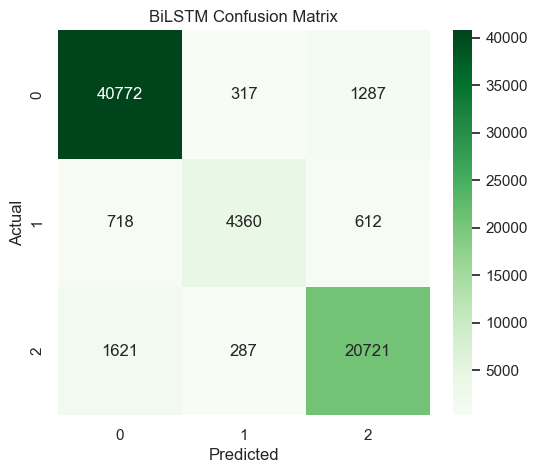

In [ ]:
# BiLSTM Confusion Matrix
cm = confusion_matrix(
    y_test_dl,
    bilstm_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

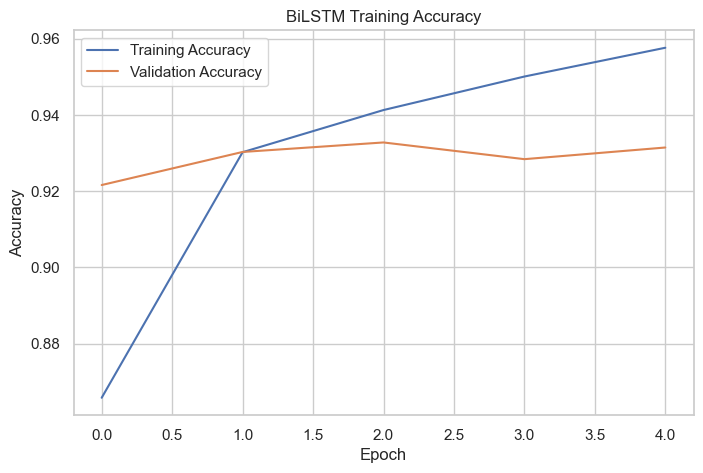

In [ ]:
# BiLSTM Training Curve
plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_bilstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("BiLSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
bilstm_model.save('bilstm_model.keras')
print("BiLSTM model saved successfully.")

BiLSTM model saved successfully.


The BiLSTM model is saved for future use during visualizations.

### 19.3 Comparison of All Models

In [90]:
import pandas as pd

comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression", 
        "Naive Bayes", 
        "SVM", 
        "LSTM", 
        "BiLSTM"
    ],
    "Accuracy": [
        0.8312,  # Logistic Regression
        0.7090,  # Naive Bayes
        0.8382,  # SVM (Tuned)
        0.9296,  # Standard LSTM
        0.9315   # Bidirectional LSTM
    ],
    "F1 Score": [
        0.7634,  # Logistic Regression
        0.6318,  # Naive Bayes
        0.7708,  # SVM (Tuned)
        0.8902,  # Standard LSTM
        0.8961   # Bidirectional LSTM
    ]
})

# Display the final polished results table
comparison_results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.8312,0.7634
1,Naive Bayes,0.7090,0.6318
2,SVM,0.8382,0.7708
3,LSTM,0.9296,0.8902
4,BiLSTM,0.9315,0.8961


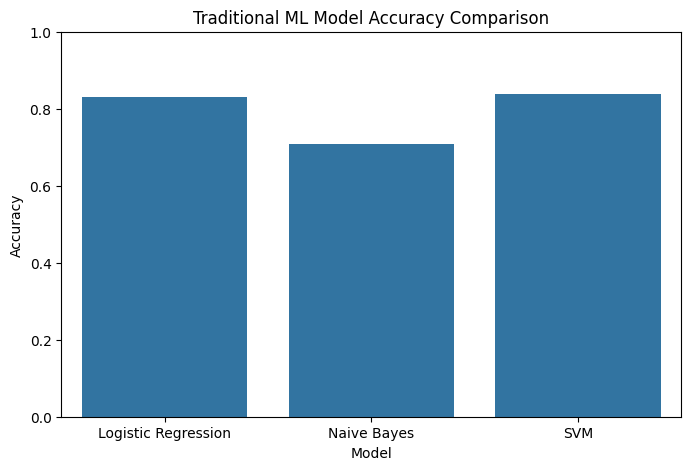

In [102]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Traditional ML Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

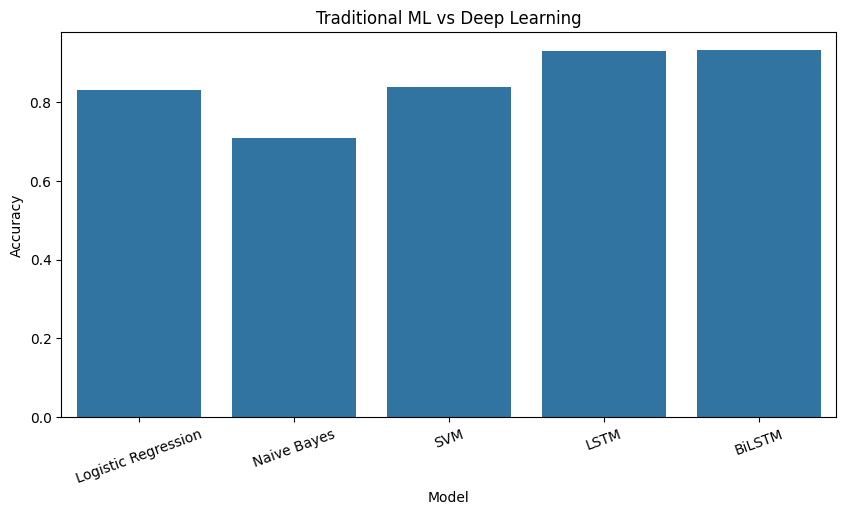

In [103]:
# Accuracy Graph
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_results,
    x='Model',
    y='Accuracy'
)

plt.title(
    "Traditional ML vs Deep Learning"
)

plt.xticks(rotation=20)

plt.show()

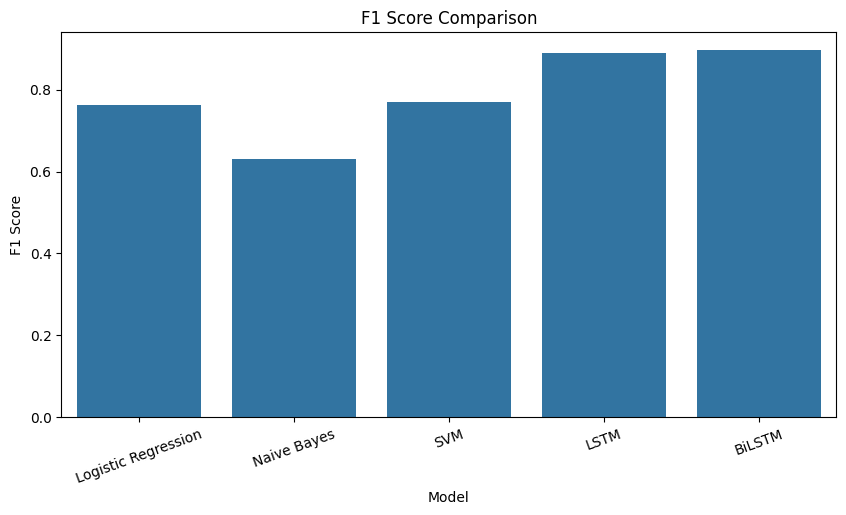

In [104]:
# F1-Score Graph
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_results,
    x='Model',
    y='F1 Score'
)

plt.title(
    "F1 Score Comparison"
)

plt.xticks(rotation=20)

plt.show()

## 20. Transformer Model

Traditional deep learning models such as LSTM and BiLSTM process text sequentially and have demonstrated strong performance in sentiment classification. However, these models may struggle to fully capture long-range contextual dependencies within complex social media discussions.

To overcome this limitation, a transformer-based approach was implemented. Transformers utilize a self-attention mechanism that enables the model to analyze relationships between words regardless of their positions within a sentence. This allows the model to better understand contextual meaning, semantic relationships, and emotional expressions found in Reddit discussions related to the Palestine–Israel conflict.

### 20.1 Emotion Detection using DistilBERT

In addition to sentiment classification, emotion detection was performed to provide deeper insights into public reactions and opinions. While sentiment analysis categorizes text into positive, negative, or neutral classes, emotion detection identifies specific emotional states expressed by users.

For this task, a pre-trained DistilBERT-based emotion classification model was employed. DistilBERT is a lightweight version of BERT that maintains strong language understanding capabilities while requiring fewer computational resources. The model was used to classify Reddit comments into emotion categories such as anger, fear, sadness, joy, surprise, and neutral emotions.

The objective of this analysis is to identify the dominant emotions present in online discussions and understand how users emotionally respond to events related to the Palestine–Israel conflict.

In [ ]:
!pip install transformers datasets accelerate evaluate -q

In [ ]:
from transformers import pipeline

# Load pre-trained model
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base"
)

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
# Create dataset for emotion dectection
emotion_df = df.copy()

emotion_df = emotion_df[
    ['clean_text', 'subreddit', 'created_time']
].copy()

emotion_df.head()

,clean_text,subreddit,created_time
0,gaza floatila activists beaten up and detained...,IsraelPalestine,2026-05-24 07:15:09
1,gaza floatila activists beaten up and detained...,IsraelPalestine,2026-05-24 07:14:48
2,more thoughts on the kristof opinion editorial...,IsraelPalestine,2026-05-24 07:14:26
3,an investigation into sexual assault in the is...,IsraelPalestine,2026-05-24 07:11:45
4,clashes in spain gaza flotilla activists beate...,worldnews,2026-05-24 07:10:46


In [ ]:
# Predict emotions
emotion_sample = emotion_df.head(1000).copy()

emotion_results = emotion_classifier(
    emotion_sample['clean_text'].tolist(),
    truncation=True,
    max_length=512
)

In [ ]:
# Save emotion labels
emotion_sample['emotion'] = [
    result['label']
    for result in emotion_results
]

emotion_sample.head()

,clean_text,subreddit,created_time,emotion
0,gaza floatila activists beaten up and detained...,IsraelPalestine,2026-05-24 07:15:09,anger
1,gaza floatila activists beaten up and detained...,IsraelPalestine,2026-05-24 07:14:48,anger
2,more thoughts on the kristof opinion editorial...,IsraelPalestine,2026-05-24 07:14:26,neutral
3,an investigation into sexual assault in the is...,IsraelPalestine,2026-05-24 07:11:45,disgust
4,clashes in spain gaza flotilla activists beate...,worldnews,2026-05-24 07:10:46,sadness


### 20.2 Emotion Distribution

This analysis provides an overview of the most frequently expressed emotions within the dataset. Understanding the dominant emotions helps reveal the overall emotional tone of discussions surrounding the Palestine–Israel conflict and highlights how users react to ongoing events.

In [ ]:
# Emotion Distribution
emotion_counts = (
    emotion_sample['emotion']
    .value_counts()
)

emotion_counts

emotion
anger       476
neutral     196
sadness      90
fear         77
disgust      63
surprise     58
joy          40
Name: count, dtype: int64

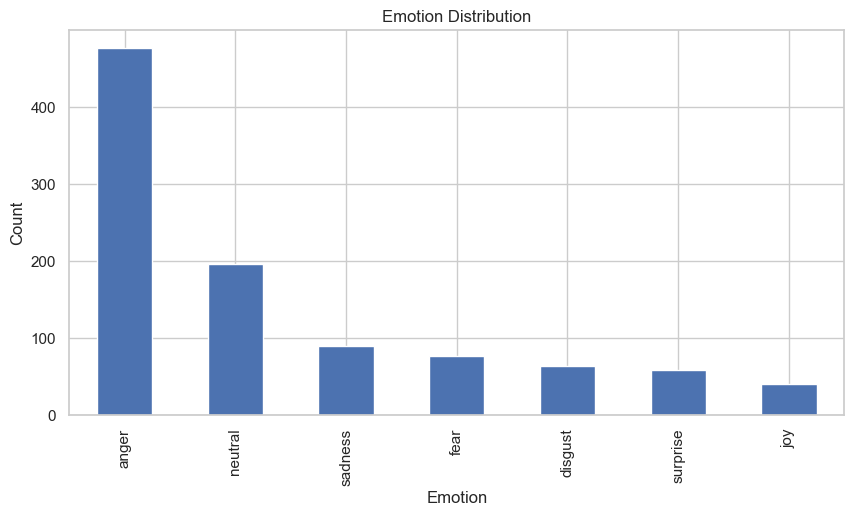

In [ ]:
# Bar Chart
plt.figure(figsize=(10,5))

emotion_counts.plot(
    kind='bar'
)

plt.title(
    'Emotion Distribution'
)

plt.xlabel('Emotion')
plt.ylabel('Count')

plt.show()

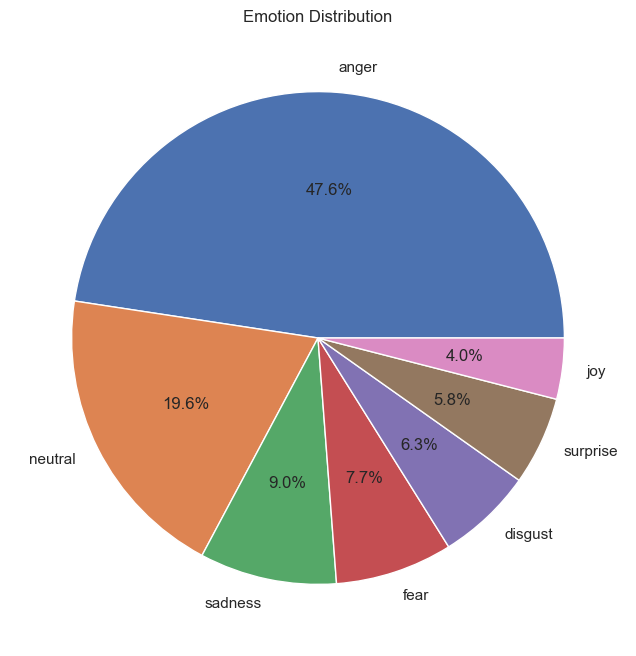

In [ ]:
# Pie Chart
plt.figure(figsize=(8,8))

emotion_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title(
    'Emotion Distribution'
)

plt.show()

### 20.3 Emotion Distribution by Subreddit

Different subreddits may exhibit distinct emotional characteristics due to variations in community interests, perspectives, and discussion topics. Therefore, emotion distributions were analyzed across individual subreddits. This analysis helps identify whether certain communities are more likely to express emotions such as anger, fear, sadness, or support compared to others.

In [ ]:
emotion_subreddit = pd.crosstab(
    emotion_sample['subreddit'],
    emotion_sample['emotion']
)

emotion_subreddit

emotion,anger,disgust,fear,joy,neutral,sadness,surprise
subreddit,,,,,,,
AskMiddleEast,6,0,0,1,4,3,5
CombatFootage,1,0,0,0,2,0,0
CrazyFuckingVideos,7,4,6,5,39,1,7
IsraelPalestine,203,12,25,23,106,22,28
NoahGetTheBoat,0,0,1,0,0,0,0
NonCredibleDefense,0,0,0,0,1,0,0
Palestine,25,31,7,3,9,7,6
PublicFreakout,2,7,5,1,1,0,0
worldnews,226,5,31,3,27,55,8


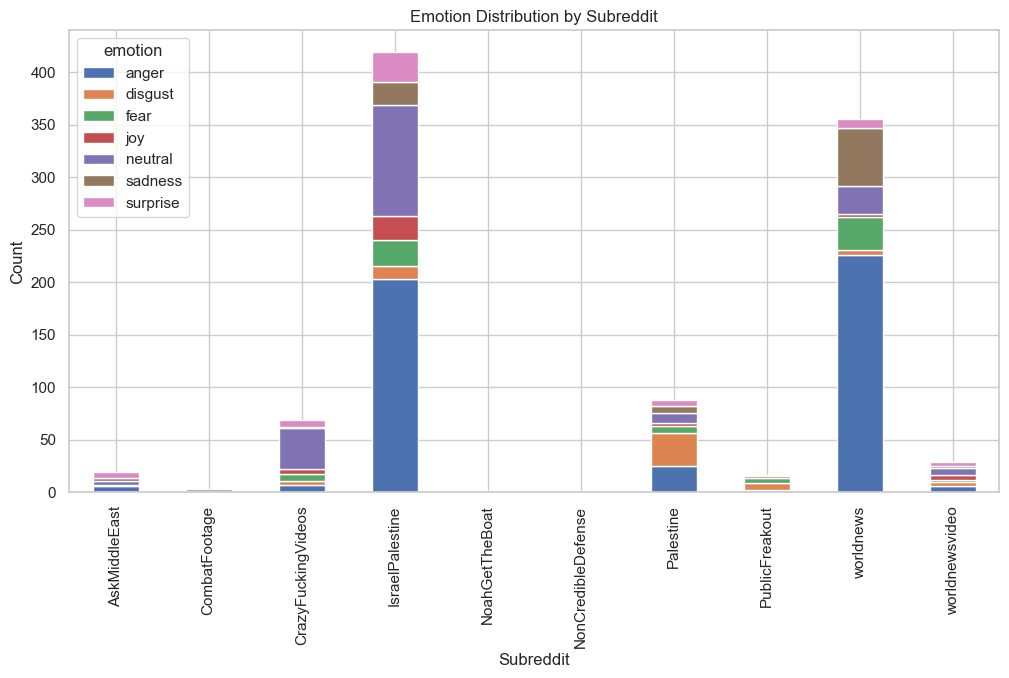

In [ ]:
# Stacked Chart
emotion_subreddit.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title(
    'Emotion Distribution by Subreddit'
)

plt.xlabel('Subreddit')
plt.ylabel('Count')

plt.show()

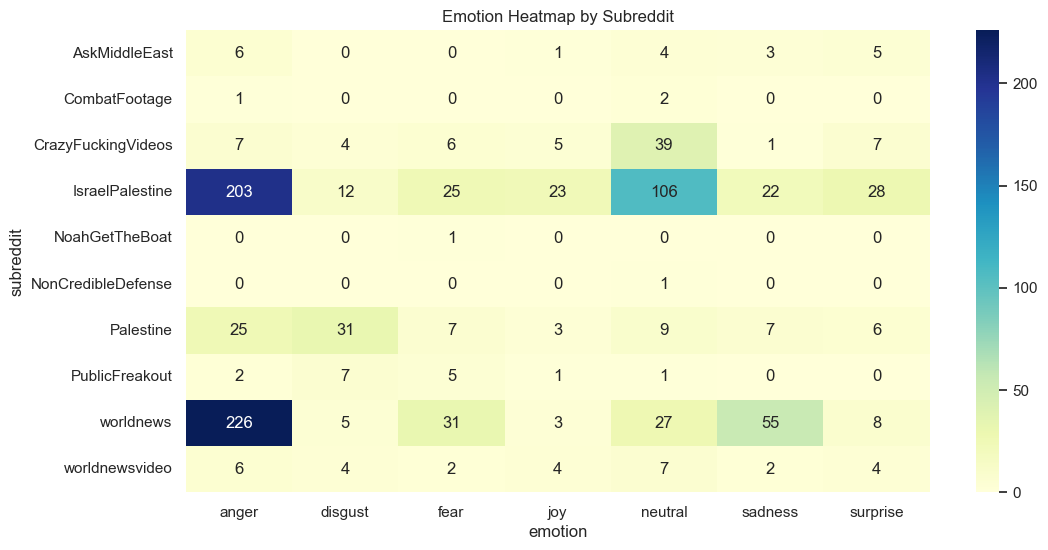

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    emotion_subreddit,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title(
    'Emotion Heatmap by Subreddit'
)

plt.show()

### 20.4 Emotion Trend Over Time

Public emotions are not static and may change in response to significant real-world events. To investigate these changes, emotion trends were analyzed over time using the comment timestamps available in the dataset. This temporal analysis provides insights into how emotional responses evolved throughout the discussion period and highlights periods of heightened emotional activity.

In [ ]:
emotion_sample['created_time'] = pd.to_datetime(
    emotion_sample['created_time']
)

emotion_sample['date'] = (
    emotion_sample['created_time']
    .dt.date
)

In [ ]:
# Daily Emotion Trends
daily_emotions = pd.crosstab(
    emotion_sample['date'],
    emotion_sample['emotion']
)

daily_emotions.head()

emotion,anger,disgust,fear,joy,neutral,sadness,surprise
date,,,,,,,
2026-05-23,174,43,44,21,120,53,35
2026-05-24,302,20,33,19,76,37,23


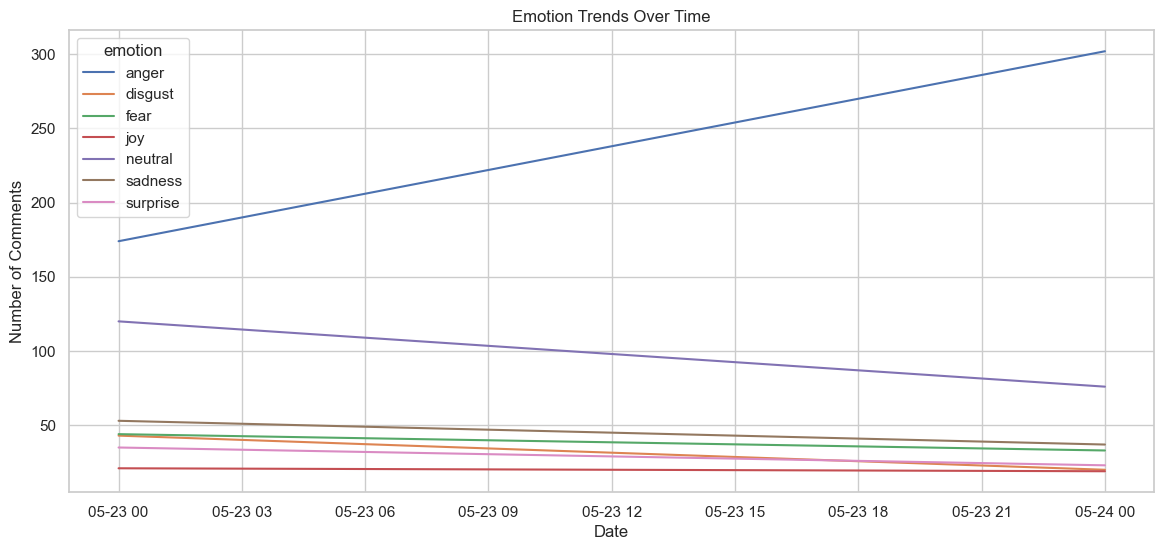

In [ ]:
# Graph
daily_emotions.plot(
    figsize=(14,6)
)

plt.title(
    'Emotion Trends Over Time'
)

plt.xlabel('Date')
plt.ylabel('Number of Comments')

plt.show()

## 21. Opinion & Aspect-Based Sentiment Mining

In [86]:
import nltk
from collections import Counter

def extract_aspect_sentiment(dataframe, text_col, target_aspects):
    """
    Extracts sentences containing target aspects and evaluates their structural sentiment.
    """
    aspect_results = {aspect: {'positive': 0, 'neutral': 0, 'negative': 0} for aspect in target_aspects}
    
    # Isolate documents containing our key aspect keywords
    for text, sentiment in zip(dataframe[text_col].fillna(""), dataframe['sentiment']):
        text_lower = text.lower()
        for aspect in target_aspects:
            if aspect in text_lower:
                aspect_results[aspect][sentiment] += 1
                
    return pd.DataFrame(aspect_results).T

# Define the central political/geopolitical entities driving polarization
core_aspects = ['palestine', 'israel', 'gaza', 'hamas', 'un', 'peace', 'war', 'civilian']
aspect_df = extract_aspect_sentiment(df, 'processed_text', core_aspects)

print("\n=== Aspect-Based Sentiment Distribution Matrix ===")
display(aspect_df)


=== Aspect-Based Sentiment Distribution Matrix ===


,positive,neutral,negative
palestine,11267,1698,13267
israel,54075,12243,119132
gaza,11498,1896,21791
hamas,4775,704,12504
un,47176,8068,90352
peace,9426,291,6022
war,12324,1598,46650
civilian,2354,472,10854


In [ ]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


## 22. Data and Sentiment Visualizations

### 22.1 Overall Sentiment Class Distribution

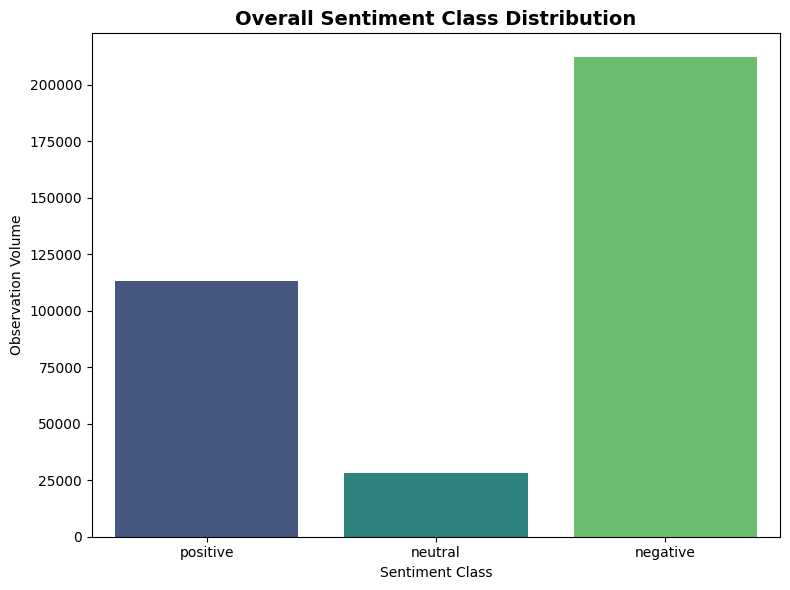

In [87]:
plt.figure(figsize=(8, 6))

sns.countplot(
    x='sentiment',
    data=df,
    palette='viridis',
    order=['positive', 'neutral', 'negative']
)

plt.title('Overall Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Class')
plt.ylabel('Observation Volume')

plt.tight_layout()
plt.show()

### 22.2 Word Cloud of Top Corpus Tokens

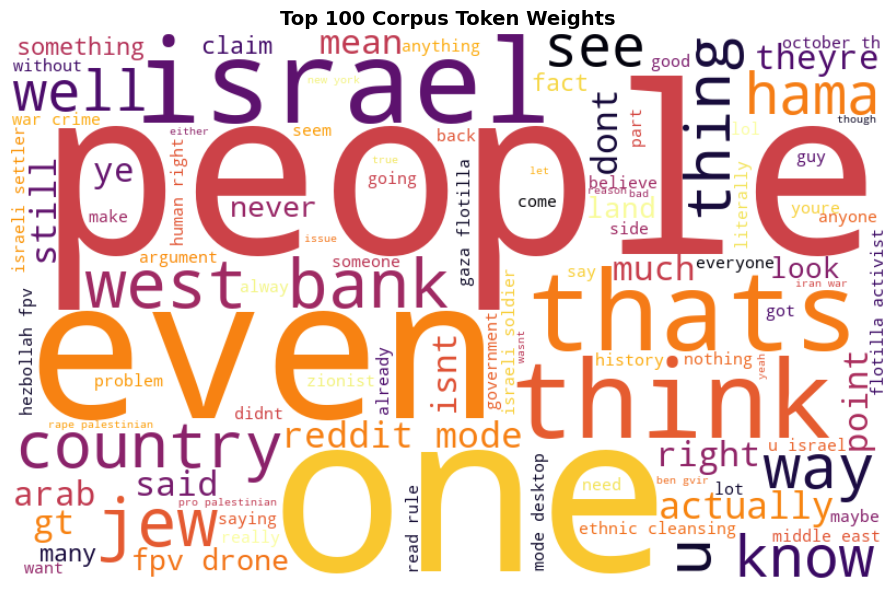

In [88]:
from wordcloud import WordCloud

combined_corpus = " ".join(
    df['processed_text'].astype(str).dropna().head(50000)
)

wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='white',
    max_words=100,
    colormap='inferno'
).generate(combined_corpus)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Corpus Token Weights', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 22.3 Aspect-Based Sentiment Distribution

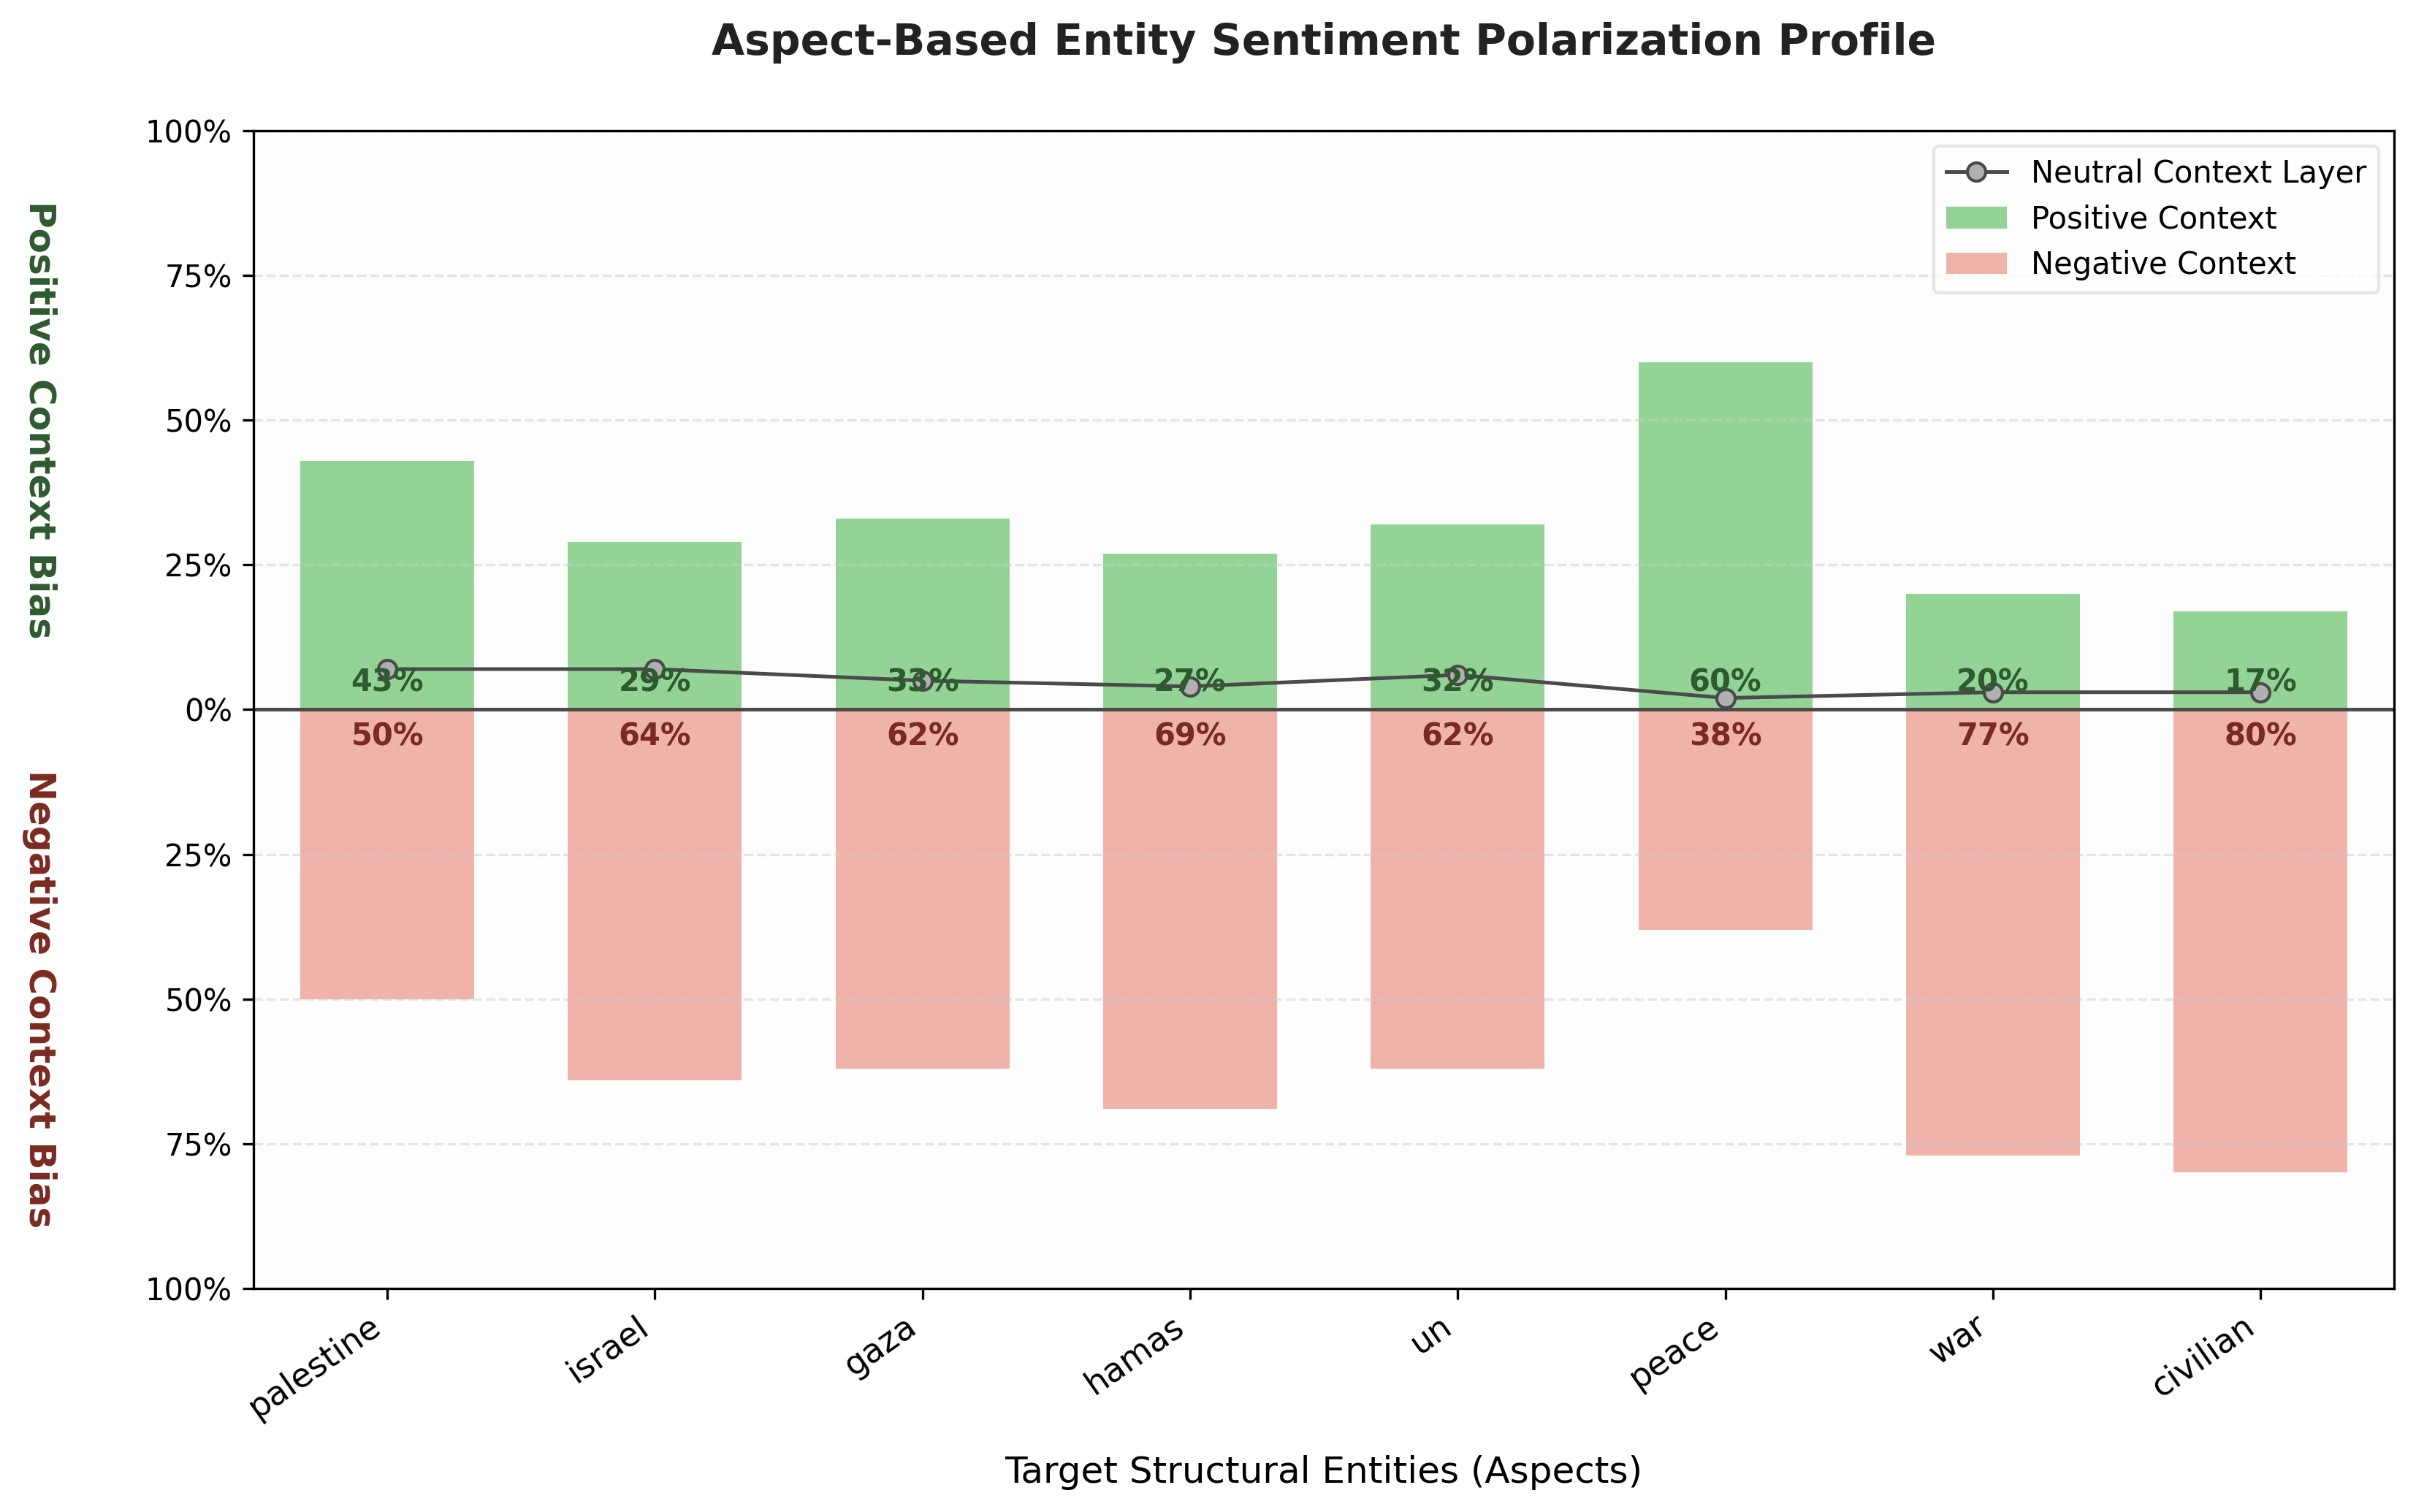

In [105]:
data = pd.DataFrame({
    "Aspect": ["palestine", "israel", "gaza", "hamas", "un", "peace", "war", "civilian"],
    "Positive": [43.0, 29.0, 33.0, 27.0, 32.0, 60.0, 20.0, 17.0],
    "Negative": [50.0, 64.0, 62.0, 69.0, 62.0, 38.0, 77.0, 80.0],
    "Neutral":  [7.0,  7.0,  5.0,  4.0,  6.0,  2.0,  3.0,  3.0]
})

fig, ax = plt.subplots(figsize=(11, 7), dpi=300)
ax.set_facecolor('#fdfdfd')
fig.patch.set_facecolor('#ffffff')

x = np.arange(len(data["Aspect"]))
width = 0.65

bars_pos = ax.bar(x, data["Positive"], width, color='#93d396', edgecolor='none', label='Positive Context')

bars_neg = ax.bar(x, -data["Negative"], width, color='#f0b3aa', edgecolor='none', label='Negative Context')

ax.plot(x, data["Neutral"], color='#4a4a4a', linestyle='-', marker='o', 
        markersize=6, markerfacecolor='#b0b0b0', markeredgecolor='#4a4a4a', 
        linewidth=1.2, label='Neutral Context Layer')

for i, bar in enumerate(bars_pos):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., 2.0, f"{int(height)}%",
            ha='center', va='bottom', fontsize=10, color='#2e5a30', weight='bold')

for i, bar in enumerate(bars_neg):
    height = bar.get_height() 
    ax.text(bar.get_x() + bar.get_width()/2., -2.0, f"{int(abs(height))}%",
            ha='center', va='top', fontsize=10, color='#7a2a21', weight='bold')

ax.set_ylim(-100, 100)
ax.set_xlim(-0.5, len(x) - 0.5)

ax.set_yticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
ax.set_yticklabels(['100%', '75%', '50%', '25%', '0%', '25%', '50%', '75%', '100%'])

ax.axhline(0, color='#4a4a4a', linewidth=1.2) 
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

ax.set_xticks(x)
ax.set_xticklabels(data["Aspect"], rotation=35, ha='right', fontsize=11, weight='medium')

ax.set_title("Aspect-Based Entity Sentiment Polarization Profile", fontsize=14, weight='bold', pad=25, color='#222222')
ax.set_xlabel("Target Structural Entities (Aspects)", fontsize=12, labelpad=10)

ax.text(-1.3, 50, 'Positive Context Bias', rotation=270, ha='center', va='center', fontsize=12, color='#2e5a30', weight='bold')
ax.text(-1.3, -50, 'Negative Context Bias', rotation=270, ha='center', va='center', fontsize=12, color='#7a2a21', weight='bold')

ax.legend(loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='#e0e0e0')

plt.tight_layout()
plt.savefig('entity_sentiment_polarization_small.png', dpi=300, bbox_inches='tight')
plt.show()